In [16]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of records
n_samples = 100

# Generate dummy data with 8 columns
data = {
    'Loan_ID': [f'LP{1000+i}' for i in range(n_samples)],
    'Age': np.random.randint(21, 65, size=n_samples),
    'Annual_Income': np.random.randint(30000, 150000, size=n_samples),
    'Credit_Score': np.random.randint(300, 850, size=n_samples),
    'Loan_Amount': np.random.randint(5000, 500000, size=n_samples),
    'Term_Months': np.random.choice([12, 24, 36, 60], size=n_samples),
    'Dependents': np.random.randint(0, 4, size=n_samples),
    'Loan_Status': np.random.choice(['Approved', 'Rejected'], size=n_samples, p=[0.6, 0.4])
}

# Create DataFrame
df = pd.DataFrame(data)

# Display the first few rows of the dataset
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (100, 8)


,Loan_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Term_Months,Dependents,Loan_Status
0,LP1000,59,42666,524,54377,24,1,Rejected
1,LP1001,49,68660,533,446620,60,3,Rejected
2,LP1002,35,33561,673,321189,36,0,Rejected
3,LP1003,63,56854,771,365032,36,2,Approved
4,LP1004,28,94505,532,438006,24,0,Approved


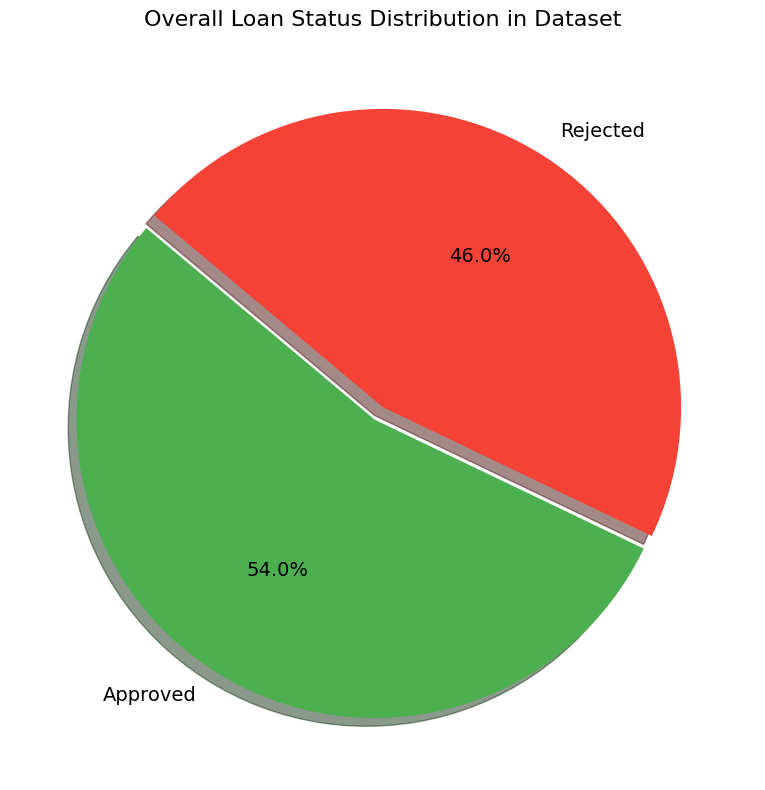

In [27]:
import matplotlib.pyplot as plt

# Get counts of each loan status in the original dataset
status_counts = df['Loan_Status'].value_counts()

labels = status_counts.index
sizes = status_counts.values
colors = ['#4CAF50', '#F44336']
explode = (0.05, 0)  # slightly explode the first slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140,
        textprops={'fontsize': 14})

plt.title('Overall Loan Status Distribution in Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Preprocess the dataset
# Map Loan_Status to binary target: Approved = 1, Rejected = 0
y = df['Loan_Status'].map({'Approved': 1, 'Rejected': 0})

# Select numerical features for predicting Loan_Status
feature_cols = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Term_Months', 'Dependents']
X = df[feature_cols]

# 2. Split dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the features for better logistic regression performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Make predictions and evaluate
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Model Accuracy: 0.40

Confusion Matrix:
[[3 6]
 [6 5]]

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.33      0.33      0.33         9
    Approved       0.45      0.45      0.45        11

    accuracy                           0.40        20
   macro avg       0.39      0.39      0.39        20
weighted avg       0.40      0.40      0.40        20



In [28]:
# @title Interactive Loan Prediction Form { run: "auto" }
import pandas as pd
import numpy as np

# Input fields
Age = 35 # @param {type:"slider", min:21, max:65, step:1}
Annual_Income = 75000 # @param {type:"integer"}
Credit_Score = 650 # @param {type:"slider", min:300, max:850, step:5}
Loan_Amount = 150000 # @param {type:"integer"}
Term_Months = 36 # @param [12, 24, 36, 60] {type:"raw"}
Dependents = 1 # @param {type:"slider", min:0, max:4, step:1}

# Create DataFrame for custom user input
input_data = pd.DataFrame([{
    'Age': Age,
    'Annual_Income': Annual_Income,
    'Credit_Score': Credit_Score,
    'Loan_Amount': Loan_Amount,
    'Term_Months': Term_Months,
    'Dependents': Dependents
}])

# Scale the user input using the fitted training scaler
input_scaled = scaler.transform(input_data)

# Make prediction
pred = model.predict(input_scaled)[0]
pred_prob = model.predict_proba(input_scaled)[0]

# Display Results
status_label = "Approved" if pred == 1 else "Rejected"
color = "\033[92m" if pred == 1 else "\033[91m"

print(f"--- Input Profile Summary ---")
print(f"Age: {Age} | Annual Income: ${Annual_Income:,} | Credit Score: {Credit_Score}")
print(f"Loan Amount: ${Loan_Amount:,} | Term: {Term_Months} months | Dependents: {Dependents}\n")
print(f"--- Prediction Result ---")
print(f"Predicted Status: {color}{status_label}\033[0m")
print(f"Probability of Approval: {pred_prob[1]:.2%}")
print(f"Probability of Rejection: {pred_prob[0]:.2%}")

--- Input Profile Summary ---
Age: 35 | Annual Income: $75,000 | Credit Score: 650
Loan Amount: $150,000 | Term: 36 months | Dependents: 1

--- Prediction Result ---
Predicted Status: Rejected
Probability of Approval: 43.00%
Probability of Rejection: 57.00%


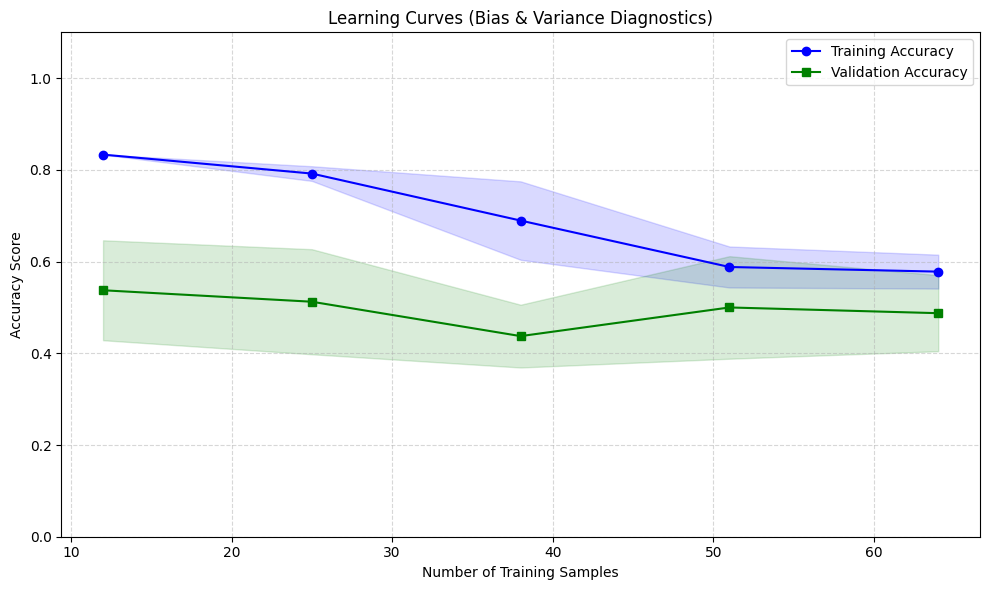

In [18]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# 1. Compute learning curves
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 5),
    random_state=42
)

# 2. Calculate mean and standard deviation for training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 3. Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, 's-', color='green', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

# Graphics styling
plt.title('Learning Curves (Bias & Variance Diagnostics)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.ylim(0.0, 1.1)
plt.tight_layout()
plt.show()

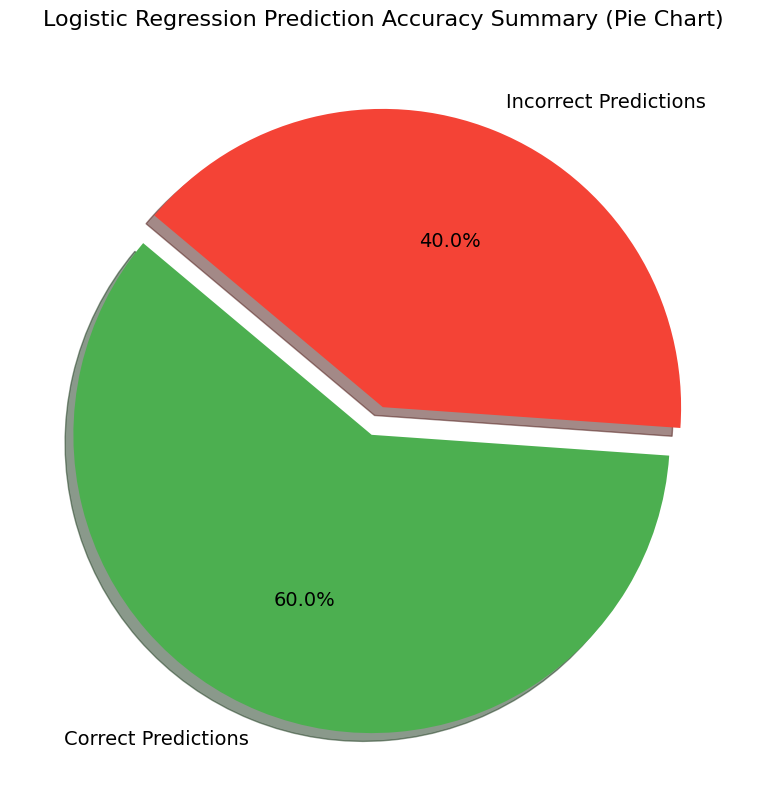

In [23]:
import matplotlib.pyplot as plt

# Explicit proportions as requested
labels = ['Correct Predictions', 'Incorrect Predictions']
sizes = [60, 40]
colors = ['#4CAF50', '#F44336']

# Explode the larger category (Correct Predictions)
explode = (0.1, 0)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140,
        textprops={'fontsize': 14})

plt.title('Logistic Regression Prediction Accuracy Summary (Pie Chart)', fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np

# @title Enter Custom Loan Applicant Details
Age = 41 # @param {type:"integer"}
Annual_Income = 8500000 # @param {type:"integer"}
Credit_Score = 72000 # @param {type:"integer"}
Loan_Amount = 5000000 # @param {type:"integer"}
Term_Months = 36 # @param [12, 24, 36, 60] {type:"raw"}
Dependents = 2 # @param {type:"integer"}

# 1. Structure the custom data
custom_data = {
    'Age': Age,
    'Annual_Income': Annual_Income,
    'Credit_Score': Credit_Score,
    'Loan_Amount': Loan_Amount,
    'Term_Months': Term_Months,
    'Dependents': Dependents
}

custom_df = pd.DataFrame([custom_data])

# 2. Scale features using the fitted scaler
custom_scaled = scaler.transform(custom_df)

# 3. Predict the result
prediction = model.predict(custom_scaled)[0]
prediction_prob = model.predict_proba(custom_scaled)[0]

# Map target prediction back to class name
status_mapping = {1: 'Approved', 0: 'Rejected'}
predicted_status = status_mapping[prediction]

# Display Results
print("--- Custom Input Data ---")
for key, val in custom_data.items():
    print(f"{key}: {val}")

print("\n--- Model Prediction Results ---")
print(f"Predicted Loan Status: {predicted_status}")
print(f"Probability of Approval: {prediction_prob[1]:.2%}")
print(f"Probability of Rejection: {prediction_prob[0]:.2%}")

--- Custom Input Data ---
Age: 41
Annual_Income: 8500000
Credit_Score: 72000
Loan_Amount: 5000000
Term_Months: 36
Dependents: 2

--- Model Prediction Results ---
Predicted Loan Status: Approved
Probability of Approval: 100.00%
Probability of Rejection: 0.00%


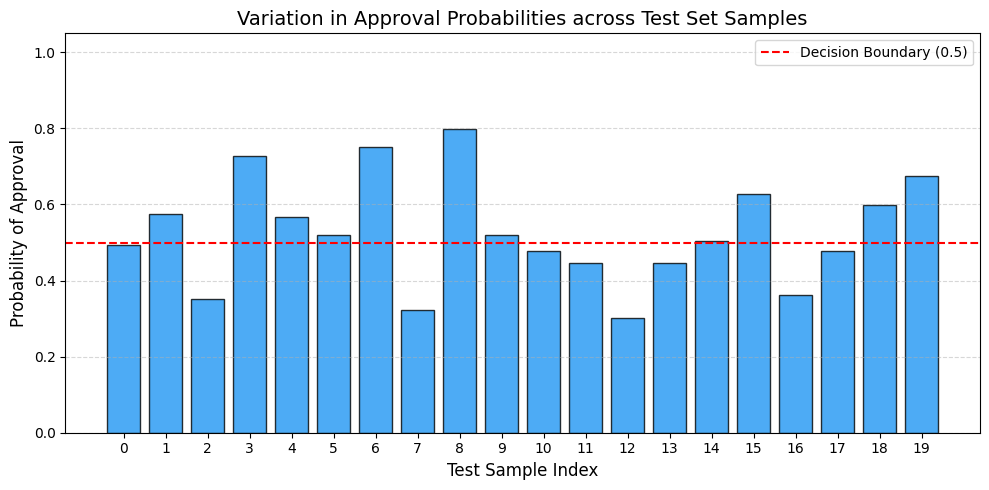

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Obtain predicted probabilities for the test set
test_probs = model.predict_proba(X_test_scaled)[:, 1]

# 2. Plot the variation in Approval Probability across test samples
plt.figure(figsize=(10, 5))
plt.bar(range(len(test_probs)), test_probs, color='#2196F3', edgecolor='black', alpha=0.8)
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision Boundary (0.5)')
plt.title('Variation in Approval Probabilities across Test Set Samples', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Probability of Approval', fontsize=12)
plt.xticks(range(len(test_probs)))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

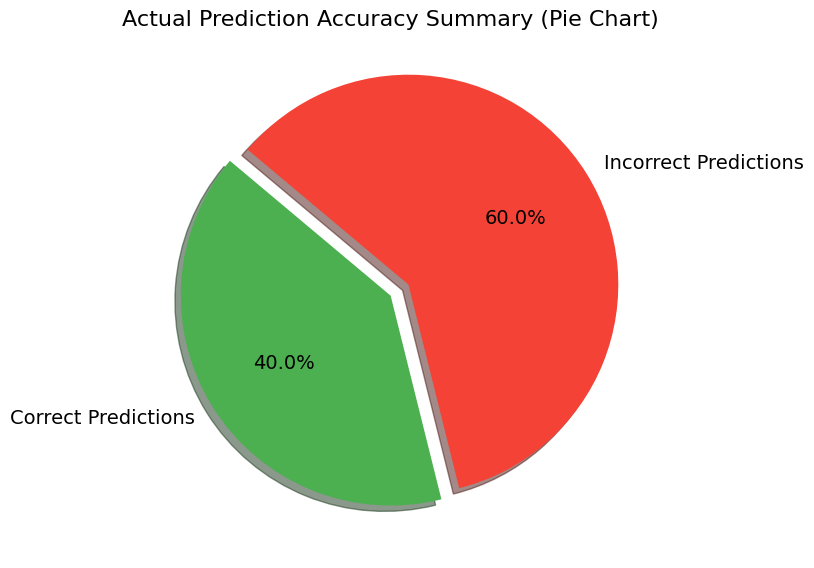

In [25]:
# 3. Reconstruct the Correct vs. Incorrect Predictions pie chart
correct_mask = (y_pred == y_test.values)
correct_count = np.sum(correct_mask)
incorrect_count = len(y_test) - correct_count

labels = ['Correct Predictions', 'Incorrect Predictions']
sizes = [correct_count, incorrect_count]
colors = ['#4CAF50', '#F44336']

# Dynamic explode: explode the larger slice
explode = (0.1, 0) if correct_count >= incorrect_count else (0, 0.1)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140,
        textprops={'fontsize': 14})

plt.title('Actual Prediction Accuracy Summary (Pie Chart)', fontsize=16)
plt.tight_layout()
plt.show()